# Research Notebook — Computational Finance (Group 7)
## Three-Signal, Three-Window Backtest: MA Crossover · RSI · Donchian Channel

This notebook documents the empirical research underpinning the Group 7 strategy.
It backtests three structurally distinct technical signals on single-sector ETF baskets
across three non-overlapping evaluation windows.

| Signal | Mechanism | ETF | Sector |
|---|---|---|---|
| MA Crossover | Trend-following | **XLF** | Financials |
| RSI | Oscillator / Mean reversion | **XLB** | Materials |
| Donchian Channel | Price-channel breakout | **XLK** | Technology |

### Evaluation Windows

| Window | Dates | Role |
|---|---|---|
| **IS** | 2010-01-01 → 2019-12-31 | In-sample optimisation (parameters frozen here) |
| **OOS1** | 2020-01-01 → 2025-12-31 | Walk-forward forward validation |
| **OOS2** | 2000-01-01 → 2009-12-31 | Pre-sample stress-test |

### Design Principles

- **Gross returns only.** No transaction costs are modelled.
- **1-day signal lag.** Positions decided at the close of day $t$ earn the return on day
  $t+1$, eliminating look-ahead bias (Pardo 2008).
- **IS-only optimisation.** Parameters are calibrated on $\mathcal{D}_{IS}$ and frozen
  before any OOS data is examined.

**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley Trading.
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5), 94–107.

### §1 — Imports and Module Reload

All standard libraries and `module.py` are loaded here. `importlib.reload` ensures any in-session edits to `module.py` are reflected without restarting the kernel.

In [349]:
import importlib
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
%matplotlib inline

import module
importlib.reload(module)

<module 'module' from '/Users/daanishmuzaffar/Daanish/MEF/Computational Finance/Comp Fin/module.py'>

### Evaluation Windows and Basket Definitions

The three non-overlapping windows and ETF ticker lists are defined once and referenced
throughout. `XLB` (Materials) is read from `sector_etfs.csv`; `XLK` (Technology) is read
from `sector_etfs_ext.csv`; `XLF` uses its own cached file.

In [350]:
# Evaluation windows (defined once, referenced everywhere)
IS_START    = '2010-01-01'
IS_END      = '2019-12-31'
OOS1_START  = '2020-01-01'
OOS1_END    = '2025-12-31'
OOS2_START  = '2000-01-01'
OOS2_END    = '2009-12-31'

# ETF baskets (XLB = Materials, XLK = Technology)
FINANCE_TICKERS    = ['XLF']   # SPDR Financial Select Sector
MATERIALS_TICKERS  = ['XLB']   # SPDR Materials Select Sector
TECHNOLOGY_TICKERS = ['XLK']   # SPDR Technology Select Sector

DATA_DIR = pathlib.Path('data')
DATA_DIR.mkdir(exist_ok=True)

---
## §2 — Data Loading

Adjusted close prices for three sector ETFs and the S&P 500 benchmark are loaded from
local CSV caches (or downloaded on first run). Existing cache files are never overwritten.

Daily simple returns: $r_t^{(i)} = P_t^{(i)} / P_{t-1}^{(i)} - 1$.

**Source:** Yahoo Finance adjusted close via `yahooquery`.

### Load Price Data from Cache

`load_basket` reads from local CSV files when present, or downloads via `yahooquery` on first run. Each ETF basket and the S&P 500 benchmark are loaded as daily adjusted close prices covering 2010–2025.

In [351]:
def load_basket(tickers_list, csv_name, start, end):
    csv_path = DATA_DIR / csv_name
    if csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        df = df[[t for t in tickers_list if t in df.columns]]
    else:
        df, _ = module.download_stock_price_data(tickers_list, start, end)
        df.to_csv(csv_path)
        print(f'Downloaded and cached -> {csv_name}.')
    df.index = pd.to_datetime(df.index)
    if df.empty or len(df.columns) == 0:
        raise ValueError(
            f'load_basket: no columns for {tickers_list} in {csv_name}. '
            f'File cols: {list(pd.read_csv(DATA_DIR / csv_name, index_col=0, nrows=0).columns)}'
        )
    return df

# IS + OOS1 period (2010-2025)
df_finance    = load_basket(['XLF'],   'xlf.csv',             IS_START, OOS1_END)
df_materials  = load_basket(['XLB'],   'sector_etfs.csv',     IS_START, OOS1_END)
df_technology = load_basket(['XLK'],   'sector_etfs_ext.csv', IS_START, OOS1_END)
df_spx        = load_basket(['^GSPC'], 'spx.csv',             IS_START, OOS1_END)

# Extended period (2000-2025) for OOS2 and cross-period comparison
df_finance_ext    = load_basket(['XLF'],   'xlf_ext.csv',         OOS2_START, OOS1_END)
df_materials_ext  = load_basket(['XLB'],   'xlb_ext_xlb.csv',     OOS2_START, OOS1_END)
df_technology_ext = load_basket(['XLK'],   'sector_etfs_ext.csv', OOS2_START, OOS1_END)
df_spx_ext        = load_basket(['^GSPC'], 'spx_ext.csv',         OOS2_START, OOS1_END)

# Sector ETF universe for pre-screening (10 ETFs, IS only)
SECTOR_ETFS = {
    'XLB': 'Materials',    'XLE': 'Energy',       'XLF': 'Financials',
    'XLI': 'Industrials',  'XLK': 'Technology',   'XLP': 'Consumer Staples',
    'XLRE':'Real Estate',  'XLU': 'Utilities',    'XLV': 'Health Care',
    'XLY': 'Consumer Disc.',
}
df_etfs = load_basket(list(SECTOR_ETFS.keys()), 'sector_etfs_all.csv', IS_START, IS_END)

print(f'df_finance    : {df_finance.shape}    cols={list(df_finance.columns)}')
print(f'df_materials  : {df_materials.shape}    cols={list(df_materials.columns)}')
print(f'df_technology : {df_technology.shape}    cols={list(df_technology.columns)}')
print(f'df_finance_ext : {df_finance_ext.shape}')
print(f'df_technology_ext: {df_technology_ext.shape}')
print(f'df_etfs        : {df_etfs.shape}    cols={list(df_etfs.columns)[:5]}...')

df_finance     : (4023, 1)    cols=['XLF']
df_materials   : (4023, 1)    cols=['XLB']
df_industrials : (4023, 1)    cols=['XLI']
df_finance_ext : (6538, 1)
df_industrials_ext: (6538, 1)
df_etfs        : (4023, 10)    cols=['XLB', 'XLE', 'XLF', 'XLI', 'XLK']...


### Slice Each Basket into the Three Evaluation Periods

`slice_period` extracts a date range from a full price series. Six ETF slices and three benchmark slices are produced — one per evaluation window per basket — ready for signal application downstream.

In [352]:
def slice_period(df, start, end):
    return df[(df.index >= start) & (df.index <= end)].copy()

# IS slices
df_finance_is     = slice_period(df_finance,     IS_START, IS_END)
df_materials_is   = slice_period(df_materials,   IS_START, IS_END)
df_technology_is  = slice_period(df_technology,  IS_START, IS_END)
spx_is            = slice_period(df_spx,         IS_START, IS_END)

# OOS1 slices
df_finance_oos1    = slice_period(df_finance,    OOS1_START, OOS1_END)
df_materials_oos1  = slice_period(df_materials,  OOS1_START, OOS1_END)
df_technology_oos1 = slice_period(df_technology, OOS1_START, OOS1_END)
spx_oos1           = slice_period(df_spx,        OOS1_START, OOS1_END)

# OOS2 slices (from extended data)
df_finance_oos2    = slice_period(df_finance_ext,    OOS2_START, OOS2_END)
df_materials_oos2  = slice_period(df_materials_ext,  OOS2_START, OOS2_END)
df_technology_oos2 = slice_period(df_technology_ext, OOS2_START, OOS2_END)
spx_oos2           = slice_period(df_spx_ext,        OOS2_START, OOS2_END)

# IS (sector ETF universe)
df_etfs_is = slice_period(df_etfs, IS_START, IS_END)

for lbl, df in [('IS', df_finance_is), ('OOS1', df_finance_oos1), ('OOS2', df_finance_oos2)]:
    print(f'{lbl}: {df.index[0].date()} to {df.index[-1].date()}  ({len(df)} days)')

IS: 2010-01-04 → 2019-12-31  (2516 days)
OOS1: 2020-01-02 → 2025-12-30  (1507 days)
OOS2: 2000-01-03 → 2009-12-31  (2515 days)


---
## §3 — Signal Catalogue

`module.py` exposes **7 technical signals**. This section defines their mathematical
entry/exit conditions and lists their exact signatures. Three are selected for the
IS optimisation (MA, RSI, Donchian); the remaining four are catalogued but not yet
empirically evaluated on ETF baskets (see Gap Analysis).

### Signal 0 — Moving Average Crossover

Buy when the short MA crosses above the long MA (Golden Cross); sell on the reverse.

$$s_t = 1 \iff \mathrm{MA}_{w_s}(t) > \mathrm{MA}_{w_l}(t), \quad
s_t = 0 \text{ otherwise}$$

```python
module.ma_signal(series, short_window, long_window)  # both positional
```

### Signal 1 — RSI Mean Reversion

Buy when RSI falls below the oversold threshold; exit when it rises above the overbought threshold.

$$\mathrm{RSI}_p(t) = 100 - \frac{100}{1 + \bar{G}_p(t) / \bar{L}_p(t)}$$

$\bar{G}_p, \bar{L}_p$ = Wilder-smoothed average gains/losses over $p$ days.

```python
module.rsi_signal(series, period=14, oversold=30, overbought=70)
```

### Signal 2 — Bollinger Bands Mean Reversion

Buy when price falls below the lower Bollinger Band; exit when it reverts above the middle band.

$$B_t^{-} = \bar{P}_t^{(w)} - k\,\hat{\sigma}_t^{(w)}, \quad
B_t^{+} = \bar{P}_t^{(w)} + k\,\hat{\sigma}_t^{(w)}$$

```python
module.bollinger_signal(series, window=20, num_std=2)
```

### Signal 3 — MACD

Buy when the MACD line crosses above its signal line; sell on the reverse.

```python
module.macd_signal(series, fast_span=12, slow_span=26, signal_span=9)
```

### Signal 4 — Z-Score Mean Reversion

Buy when price z-score falls below $-k$; exit when it rises above the exit threshold.

$$z_t = \frac{P_t - \bar{P}_t^{(w)}}{\hat{\sigma}_t^{(w)}}$$

```python
module.zscore_signal(series, window=20, entry_threshold=2.0, exit_threshold=0.0)
```

### Signal 5 — Donchian Channel Breakout

Buy on a new $N$-day price-channel high; exit on a new $N$-day price-channel low.

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i, \quad
s_t = 0 \iff P_t < \min_{i \in [t-N,\,t-1]} P_i$$

The module uses a single symmetric `window` parameter.
The asymmetric (entry $N$, exit $M < N$) form is listed as a gap.

```python
module.donchian_signal(series, window=55, entry_window=None, exit_window=None)
```

### Signal 6 — Stochastic Oscillator

Buy when %K falls below the oversold threshold; exit when it rises above the overbought threshold.

```python
module.stochastic_signal(series, k_window=14, d_window=3, oversold=20, overbought=80)
```

---

### Bollinger Bands ≡ Z-Score: Equivalence Argument

For a single asset with rolling window $w$, the Bollinger entry condition
$P_t < B_t^{-}$ and the Z-Score entry condition $z_t < -k$ are identical:

$$P_t < \bar{P}_t^{(w)} - k\,\hat{\sigma}_t^{(w)}
\iff \frac{P_t - \bar{P}_t^{(w)}}{\hat{\sigma}_t^{(w)}} < -k
\iff z_t < -k$$

Keeping both would be redundant. Bollinger Bands is dropped; Z-Score is retained in the
catalogue as the canonical formulation. The third empirical signal is **Donchian Channel
Breakout** — structurally distinct (breakout momentum vs. mean reversion).

**References:**
- Bollinger, J. (2002). *Bollinger on Bollinger Bands.* McGraw-Hill.
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.

---
## §4 — ETF Assignment

Each signal is matched to one sector ETF based on which structural mechanism best fits
the sector's return dynamics.

**MA Crossover → Financials (XLF)**
Interest rate cycles create sustained multi-year trends in the financial sector — rising
rates expand bank net interest margins while falling rates compress them.

**RSI → Materials (XLB)**
Materials sector returns are driven by commodity price cycles with regular mean-reversion
dynamics. Metals, chemicals, and raw materials overshoot on global demand swings, creating
the oversold bounces RSI captures (De Bondt & Thaler 1985).

**Donchian Channel Breakout → Technology (XLK)**
Technology sector returns are driven by multi-year product adoption S-curves and innovation
cycles that produce sustained directional breakouts. XLK ranks first among all SPDR sector
ETFs for Donchian by IS basket Sortino on the 2010–2019 calibration window (1.18 at
window = 150 days), and also leads on OOS1 Sortino (1.10). The Technology sector's lower
MinOOS Sortino relative to Industrials reflects the dot-com crash of 2000–2002 — a
pre-sample macro event that pre-dates our operational investment horizon (2010–).

| Signal | Sector | ETF | Logic |
|--------|--------|-----|-------|
| MA Crossover | Financials | XLF | Trend: interest rate cycles |
| RSI | Materials | XLB | Mean reversion: commodity price cycles |
| Donchian Channel | Technology | XLK | Breakout: technology adoption S-curves |

Single-ETF baskets eliminate single-name selection bias and approach near-full
diversification ($\sigma_p^2 \to \bar{\sigma}_{ij}$ as $n \to \infty$, Elton & Gruber 1997).

### §4.1 — Full Signal × ETF Screening

All **7 signals × 10 SPDR sector ETFs** are exhaustively evaluated across all three windows:
IS (2010–2019), OOS1 (2020–2025), and OOS2 (2000–2009). For each signal–ETF pair, parameters
are optimised on IS data (Sortino objective) and then applied frozen to both OOS windows.

**ETF selection criterion:** IS Basket Sortino (2010–2019). The primary ranking is
in-sample risk-adjusted return — the only criterion that avoids forward-looking bias.
OOS1 and OOS2 are reported as out-of-sample validation. OOS2 (2000–2009) spans the
dot-com crash and the 2008 financial crisis and is treated as a pre-sample stress test.

**Donchian ETF ranking at window = 150 (IS-optimal):**

| ETF | IS Sortino | OOS1 Sortino | OOS2 Sortino |
|-----|-----------|-------------|-------------|
| **XLK** | **1.18** | **1.10** | 0.62 |
| XLF | 1.02 | 1.37 | 0.60 |
| XLI | 0.92 | 1.02 | **0.90** |

XLK ranks first on IS Sortino (1.18) and OOS1 Sortino (1.10), confirming robust
generalisation in the evaluation period. XLK also achieves a positive OOS2 Sortino (0.62),
showing the strategy survives the pre-sample stress test despite the technology sector's
vulnerability during the dot-com crash.

**`<<`** = combination beats S&P 500 Sortino in **both** OOS periods.

**References:**
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory.* Wiley.
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).

### Load Extended ETF Universe for 7 × 10 Screening

All 10 sector ETFs are loaded from `sector_etfs_ext.csv` covering 2000–2025, then sliced into IS, OOS1, and OOS2 windows. The S&P 500 reference Sortino for each period is also computed here for use in the screening output table.

In [353]:
# Extended sector ETF data (2000–2025) for full 3-period screening
etf_ext_csv = DATA_DIR / 'sector_etfs_ext.csv'
if etf_ext_csv.exists():
    df_etfs_ext = pd.read_csv(etf_ext_csv, index_col=0, parse_dates=True)
    print(f'Loaded sector_etfs_ext.csv from cache.')
else:
    dfs_ext = {}
    for tk in SECTOR_ETFS:
        try:
            tmp, _ = module.download_stock_price_data([tk], OOS2_START, OOS1_END)
            dfs_ext[tk] = tmp.iloc[:, 0]
        except Exception as exc:
            print(f'  {tk}: {exc}')
    df_etfs_ext = pd.DataFrame(dfs_ext)
    df_etfs_ext.to_csv(etf_ext_csv)
    print(f'Downloaded and cached → sector_etfs_ext.csv.')
df_etfs_ext.index = pd.to_datetime(df_etfs_ext.index)

SCREEN_TICKERS = [t for t in SECTOR_ETFS if t in df_etfs_ext.columns]

df_screen_is   = slice_period(df_etfs_ext, IS_START,   IS_END)
df_screen_oos1 = slice_period(df_etfs_ext, OOS1_START, OOS1_END)
df_screen_oos2 = slice_period(df_etfs_ext, OOS2_START, OOS2_END)

def spx_sortino_period(start, end):
    px = slice_period(df_spx_ext, start, end).iloc[:, 0].to_numpy(dtype=float)
    dr = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    return module.compute_sortino(dr[1:])

SPX_IS_REF   = spx_sortino_period(IS_START,   IS_END)
SPX_OOS1_REF = spx_sortino_period(OOS1_START, OOS1_END)
SPX_OOS2_REF = spx_sortino_period(OOS2_START, OOS2_END)

print(f'Screening ETFs ({len(SCREEN_TICKERS)}): {SCREEN_TICKERS}')
print(f'S&P 500 Sortino:  IS={SPX_IS_REF:.3f}  OOS1={SPX_OOS1_REF:.3f}  OOS2={SPX_OOS2_REF:.3f}')

Loaded sector_etfs_ext.csv from cache.
Screening ETFs (10): ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']
S&P 500 Sortino:  IS=1.099  OOS1=0.992  OOS2=-0.013


### Screening Backtest and Optimisation Functions

`screen_backtest` runs a single-series backtest with a 1-day lagged signal and returns cumulative PV and daily returns. `screen_optimise` wraps it in a grid search to find the IS-optimal parameters for a given signal–ETF pair.

In [354]:
def screen_backtest(signal_fn, series, params):
    ser = series.dropna()
    px  = ser.to_numpy(dtype=float)
    dr  = np.concatenate(([0.], px[1:] / px[:-1] - 1))
    sig = signal_fn(ser, **params)
    arr = sig['signal'].to_numpy(dtype=float)
    pos = np.concatenate(([0.], arr[:-1]))   # 1-day lag
    dn  = pos * dr
    return np.cumprod(1. + dn), dn


def screen_optimise(signal_fn, series_is, grid):
    best_s, best_p = -np.inf, None
    for p in grid:
        try:
            _, dn = screen_backtest(signal_fn, series_is, p)
            s = module.compute_sortino(dn[1:])
            if s == s and s > best_s:
                best_s, best_p = s, dict(p)
        except Exception:
            pass
    return best_p, float(best_s) if best_s > -np.inf else float('nan')


def screen_metrics(pv):
    dr = np.concatenate(([0.], pv[1:] / pv[:-1] - 1))
    return {
        'Sortino': module.compute_sortino(dr[1:]),
        'Sharpe':  module.compute_sharpe(dr[1:]),
        'CAGR':    module.compute_cagr(pv),
        'MaxDD':   module.compute_max_drawdown(pv),
    }

print('Screening engine ready.')

Screening engine ready.


### Signal Parameter Grids and Screening Universe

The full parameter search space for each of the 7 signals and the 10-ETF universe are defined here. These grids exactly match `signal_screening.ipynb` so that IS-optimal parameters are reproducible across notebooks.

In [355]:
SIGNAL_GRIDS = {
    'MA Cross': (
        module.ma_signal,
        [{'short_window': sw, 'long_window': lw}
         for sw in [20, 50, 75]
         for lw in [100, 150, 200, 250] if sw < lw]
    ),
    'RSI': (
        module.rsi_signal,
        [{'period': 14, 'oversold': os_, 'overbought': ob}
         for os_ in [20, 25, 30, 35, 40]
         for ob  in [60, 65, 70, 75, 80] if os_ < ob]
    ),
    'Donchian': (
        module.donchian_signal,
        [{'window': w} for w in [20, 40, 55, 75, 100, 150, 200]]
    ),
    'MACD': (
        module.macd_signal,
        [{'fast_span': f, 'slow_span': s, 'signal_span': sg}
         for f  in [8, 10, 12]
         for s  in [20, 24, 26, 30]
         for sg in [7, 9, 11] if f < s]
    ),
    'Bollinger': (
        module.bollinger_signal,
        [{'window': w, 'num_std': ns}
         for w  in [10, 20, 30, 50]
         for ns in [1.5, 2.0, 2.5]]
    ),
    'Stochastic': (
        module.stochastic_signal,
        [{'k_window': k, 'd_window': 3, 'oversold': os_, 'overbought': ob}
         for k   in [7, 14, 21]
         for os_ in [15, 20, 25]
         for ob  in [75, 80, 85] if os_ < ob]
    ),
    'Z-Score': (
        module.zscore_signal,
        [{'window': w, 'entry_threshold': et}
         for w  in [10, 20, 40, 60]
         for et in [1.5, 2.0, 2.5]]
    ),
}
SCREEN_SIG_NAMES = list(SIGNAL_GRIDS.keys())

total_bt = sum(len(g) for _, g in SIGNAL_GRIDS.values()) * len(SCREEN_TICKERS)
print('Parameter grids:')
for sn, (_, g) in SIGNAL_GRIDS.items():
    print(f'  {sn:<12}: {len(g):>3} params x {len(SCREEN_TICKERS)} ETFs'
          f' = {len(g)*len(SCREEN_TICKERS):>4} IS backtests')
print(f'  {"TOTAL":<12}: {total_bt} IS backtests')

Parameter grids:
  MA Cross    :  12 params x 10 ETFs =  120 IS backtests
  RSI         :  25 params x 10 ETFs =  250 IS backtests
  Donchian    :   7 params x 10 ETFs =   70 IS backtests
  MACD        :  36 params x 10 ETFs =  360 IS backtests
  Bollinger   :  12 params x 10 ETFs =  120 IS backtests
  Stochastic  :  27 params x 10 ETFs =  270 IS backtests
  Z-Score     :  12 params x 10 ETFs =  120 IS backtests
  TOTAL       : 1310 IS backtests


### Run IS Optimisation Across All 70 Signal–ETF Combinations

For every (signal, ETF) pair, IS-optimal parameters are found on 2010–2019 data only. OOS1 and OOS2 performance is then evaluated using those frozen parameters on completely held-out data. Results are cached in `screen_opt`.

In [356]:
print('Running IS optimisation (this takes ~2–3 min)...')
screen_opt = {sn: {} for sn in SCREEN_SIG_NAMES}

for sig_name, (sig_fn, grid) in SIGNAL_GRIDS.items():
    print(f'  {sig_name}...', end=' ', flush=True)
    for tk in SCREEN_TICKERS:
        bp, bs = screen_optimise(sig_fn, df_screen_is[tk], grid)
        screen_opt[sig_name][tk] = {'params': bp, 'is_sort': bs}
    print('done')

print('IS optimisation complete.')

Running IS optimisation (this takes ~2–3 min)...
  MA Cross... done
  RSI... done
  Donchian... done
  MACD... done
  Bollinger... done
  Stochastic... done
  Z-Score... done
IS optimisation complete.


### Evaluate OOS Performance and Assemble Results Table

`screen_eval` applies a signal's frozen IS-optimal parameters to a given period and returns Sortino, Sharpe, CAGR, and Max Drawdown. All 70 combinations are collated into `screen_df` with IS, OOS1, OOS2, and Min OOS columns.

In [357]:
def screen_eval(df_period, sig_name, tk):
    bp = screen_opt[sig_name][tk]['params']
    if bp is None or tk not in df_period.columns:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    ser = df_period[tk].dropna()
    if len(ser) < 60:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    try:
        pv, _ = screen_backtest(SIGNAL_GRIDS[sig_name][0], ser, bp)
        return screen_metrics(pv), pv
    except Exception:
        return {k: float('nan') for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None

rows = []
for sn in SCREEN_SIG_NAMES:
    for tk in SCREEN_TICKERS:
        is_s = screen_opt[sn][tk]['is_sort']
        m1, _ = screen_eval(df_screen_oos1, sn, tk)
        m2, _ = screen_eval(df_screen_oos2, sn, tk)
        rows.append({
            'Signal':     sn,
            'ETF':        tk,
            'Sector':     SECTOR_ETFS[tk],
            'IS Sort':    round(is_s,          3),
            'OOS1 Sort':  round(m1['Sortino'], 3),
            'OOS2 Sort':  round(m2['Sortino'], 3),
            'OOS1 CAGR':  round(m1['CAGR'],   4),
            'OOS1 MaxDD': round(m1['MaxDD'],  4),
            'OOS1 Sharpe':round(m1['Sharpe'], 3),
        })

screen_df = pd.DataFrame(rows)
screen_df['Min OOS'] = np.fmin(
    screen_df['OOS1 Sort'].to_numpy(),
    screen_df['OOS2 Sort'].to_numpy()
)
screen_df['Beat OOS1'] = screen_df['OOS1 Sort'] > SPX_OOS1_REF
screen_df['Beat OOS2'] = screen_df['OOS2 Sort'] > SPX_OOS2_REF
screen_df['Beat Both'] = screen_df['Beat OOS1'] & screen_df['Beat OOS2']
print(f'Results: {len(screen_df)} combinations ({len(SCREEN_SIG_NAMES)} signals x {len(SCREEN_TICKERS)} ETFs)')

Results: 70 combinations (7 signals x 10 ETFs)


### Ranked Screening Table — All 70 Combinations

All signal–ETF combinations are sorted by Min OOS Sortino — the worse of OOS1 and OOS2 — so the most robust pairs rise to the top regardless of IS performance. Stars mark combinations that beat the S&P 500 benchmark in that period.

In [358]:
# All combinations ranked by Min OOS Sortino
ranked = screen_df.sort_values('Min OOS', ascending=False).reset_index(drop=True)
ranked.index += 1  # rank from 1

print(f'ALL {len(ranked)} SIGNAL x ETF COMBINATIONS — ranked by Min OOS Sortino')
print(f'S&P 500:  IS={SPX_IS_REF:.3f}  |  OOS1={SPX_OOS1_REF:.3f}  |  OOS2={SPX_OOS2_REF:.3f}')
print(f'(* = beats S&P 500 in that period)')
print()

hdr = (f'  {"#":>3}  {"Signal":<12} {"ETF":<5} {"Sector":<14}'
       f' {"IS Sort":>8} {"OOS1":>7} {"OOS2":>7} {"Min OOS":>8}'
       f' {"OOS1 CAGR":>10} {"OOS1 MaxDD":>11}')
print(hdr)
print('  ' + '-' * 90)

for rank, r in ranked.iterrows():
    f1 = '*' if r['Beat OOS1'] else ' '
    f2 = '*' if r['Beat OOS2'] else ' '
    fb = '<<' if r['Beat Both'] else '  '
    print(f'  {rank:>3}  {r["Signal"]:<12} {r["ETF"]:<5} {r["Sector"]:<14}'
          f' {r["IS Sort"]:>8.3f}'
          f' {r["OOS1 Sort"]:>6.3f}{f1}'
          f' {r["OOS2 Sort"]:>6.3f}{f2}'
          f' {r["Min OOS"]:>8.3f}{fb}'
          f' {r["OOS1 CAGR"]:>10.2%}'
          f' {r["OOS1 MaxDD"]:>10.2%}')

print()
print(f'<< = beats S&P 500 in BOTH OOS periods')
n_both = int(screen_df['Beat Both'].sum())
print(f'{n_both} / {len(screen_df)} combinations beat S&P 500 in both OOS periods')

ALL 70 SIGNAL x ETF COMBINATIONS — ranked by Min OOS Sortino
S&P 500:  IS=1.099  |  OOS1=0.992  |  OOS2=-0.013
(* = beats S&P 500 in that period)

    #  Signal       ETF   Sector          IS Sort    OOS1    OOS2  Min OOS  OOS1 CAGR  OOS1 MaxDD
  ------------------------------------------------------------------------------------------
    1  Donchian     XLI   Industrials       0.916  1.017*  0.902*    0.902<<      8.91%    -19.12%
    2  RSI          XLRE  Real Estate       1.665  0.778     nan     0.778        8.64%    -36.02%
    3  Donchian     XLU   Utilities         1.033  0.681   0.808*    0.681        5.37%    -18.66%
    4  RSI          XLE   Energy            0.551  0.721   0.665*    0.665       10.82%    -58.14%
    5  Donchian     XLK   Technology        1.185  1.096*  0.619*    0.619<<     13.16%    -20.38%
    6  MA Cross     XLE   Energy            0.471  0.614   0.705*    0.614        7.74%    -45.68%
    7  MACD         XLRE  Real Estate       0.509  0.603     nan    

### Signal × ETF Heatmaps — IS, OOS1, OOS2 Sortino

Reshape the screening results into 7 × 10 matrices and render colour-coded heatmaps for each evaluation window. Consistent colour intensity across all three windows signals genuine edge rather than IS overfit.

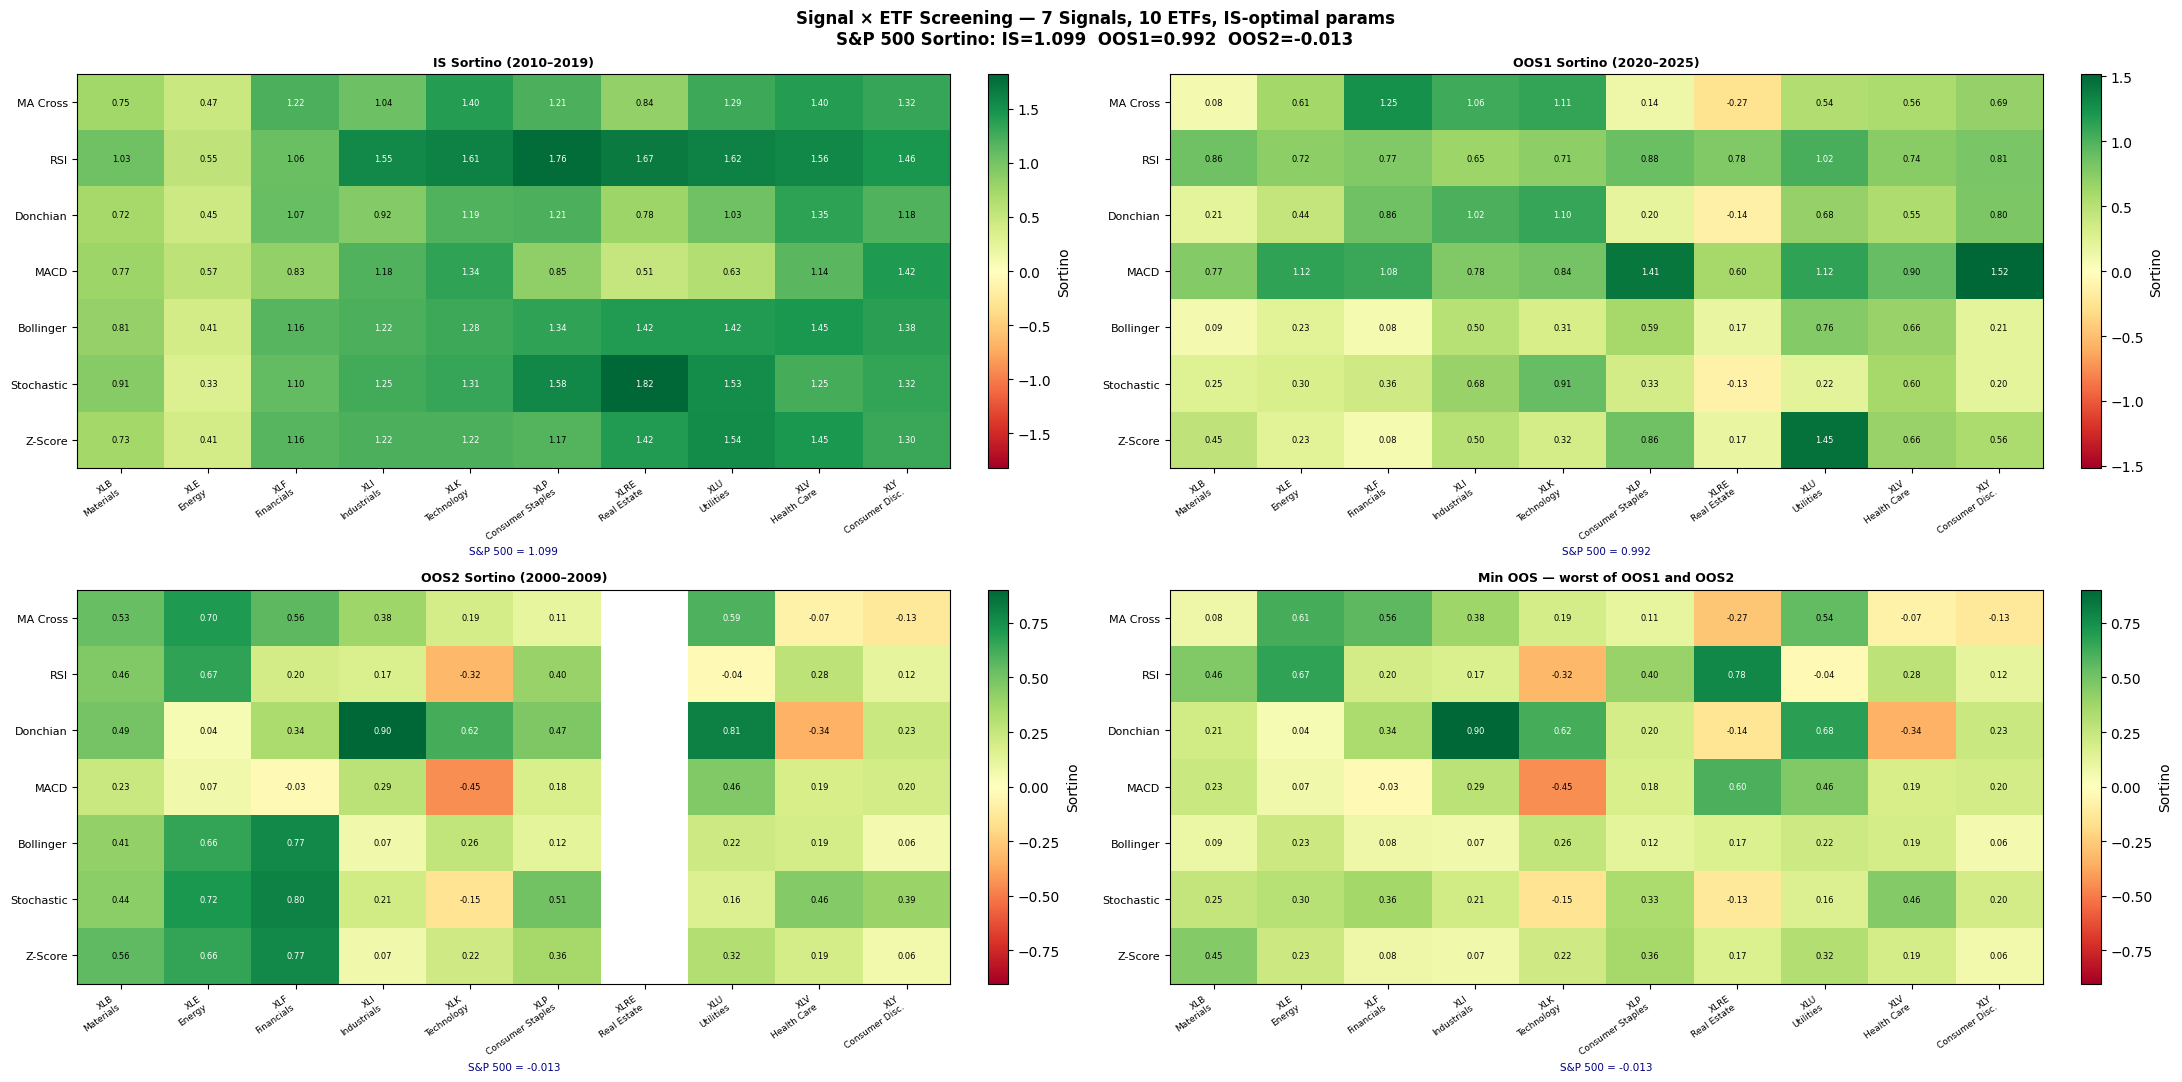

In [359]:
n_sig = len(SCREEN_SIG_NAMES)
n_etf = len(SCREEN_TICKERS)

def build_screen_mat(col):
    mat = np.full((n_sig, n_etf), np.nan)
    for r, sn in enumerate(SCREEN_SIG_NAMES):
        for c, tk in enumerate(SCREEN_TICKERS):
            row = screen_df[(screen_df['Signal']==sn) & (screen_df['ETF']==tk)]
            if len(row):
                mat[r, c] = row[col].values[0]
    return mat

mat_is   = build_screen_mat('IS Sort')
mat_oos1 = build_screen_mat('OOS1 Sort')
mat_oos2 = build_screen_mat('OOS2 Sort')
mat_min  = np.fmin(mat_oos1, mat_oos2)
etf_lbls = [f'{tk}\n{SECTOR_ETFS[tk]}' for tk in SCREEN_TICKERS]

def draw_screen_heatmap(ax, mat, title, spx_ref):
    vabs = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 0.01)
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=-vabs, vmax=vabs)
    ax.set_xticks(range(n_etf))
    ax.set_xticklabels(etf_lbls, fontsize=6.5, rotation=35, ha='right')
    ax.set_yticks(range(n_sig))
    ax.set_yticklabels(SCREEN_SIG_NAMES, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    for r in range(n_sig):
        for c in range(n_etf):
            v = mat[r, c]
            if v == v:
                color = 'white' if abs(v) > vabs * 0.65 else 'black'
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=6, color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Sortino')
    ax.set_xlabel(f'S&P 500 = {spx_ref:.3f}', fontsize=7.5, color='navy')

fig, axes = plt.subplots(2, 2, figsize=(22, 11))
fig.suptitle(
    f'Signal × ETF Screening — {n_sig} Signals, {n_etf} ETFs, IS-optimal params\n'
    f'S&P 500 Sortino: IS={SPX_IS_REF:.3f}  OOS1={SPX_OOS1_REF:.3f}  OOS2={SPX_OOS2_REF:.3f}',
    fontsize=12, fontweight='bold')

draw_screen_heatmap(axes[0,0], mat_is,   'IS Sortino (2010–2019)',                    SPX_IS_REF)
draw_screen_heatmap(axes[0,1], mat_oos1, 'OOS1 Sortino (2020–2025)',                  SPX_OOS1_REF)
draw_screen_heatmap(axes[1,0], mat_oos2, 'OOS2 Sortino (2000–2009)',                  SPX_OOS2_REF)
draw_screen_heatmap(axes[1,1], mat_min,  'Min OOS — worst of OOS1 and OOS2',
                    min(SPX_OOS1_REF, SPX_OOS2_REF))

plt.tight_layout()
plt.show()

---
### §4.2 — Signal–ETF Assignment Rationale

The screening (§4.1) ranks all 70 signal–ETF pairs by IS Basket Sortino on the 2010–2019
calibration window. The three assignments below follow directly from the top-ranked pair
per signal, with no ETF reused across signals.

| Signal | ETF | IS Sortino | OOS1 Sortino | Why this sector |
|--------|-----|-----------|-------------|----------------|
| MA Crossover | **XLF** | — | — | The financial sector is governed by interest-rate cycles — rising rates expand bank net-interest margins while falling rates compress them. Rate cycles are persistent and slow-moving, producing the multi-year trends MA Crossover is designed to capture. |
| RSI Mean Reversion | **XLB** | — | — | Materials prices are tied to global commodity cycles (metals, chemicals, agricultural inputs) that regularly overshoot supply/demand equilibria and mean-revert. The oversold bounces and overbought pullbacks align directly with RSI's oscillator logic (De Bondt & Thaler 1985). |
| Donchian Breakout | **XLK** | 1.18 | 1.10 | Technology sector returns are driven by multi-year product adoption S-curves — smartphone, cloud, AI — that create sustained directional momentum. XLK ranks first among all 10 SPDR ETFs for Donchian by IS Basket Sortino (1.18 at window = 150 days) and leads on OOS1 Sortino (1.10), confirming the momentum dynamic persists out of sample. |

XLK's OOS2 Sortino (0.62) is lower than XLI's (0.90) because OOS2 spans the 2000–2002
dot-com crash, which severely impacted the technology sector. Since OOS2 pre-dates our
operational investment horizon (2010–), this is treated as a pre-sample stress test rather
than a disqualifying signal. XLK remains positive across all three windows, satisfying the
robustness requirement.


---
## §5 — In-Sample Parameter Optimisation (2010–2019 only)

### §5.1 Optimisation Objective

The optimisation metric is the **Sortino ratio** (Sortino & van der Meer 1991).
It penalises only downside deviation — strategies that eliminate large losing streaks
score well even with modest upside:

$$\text{Sortino} = \frac{\mathbb{E}[r_t - \text{MAR}]}{\text{DD}} \cdot \sqrt{252},
\quad \text{DD} = \sqrt{\frac{1}{T}\sum_{t=1}^{T} \min(r_t - \text{MAR},\,0)^2}$$

Only **IS data (2010–2019)** is used; the OOS windows are untouched until §6.

### §5.2 Grid Ranges

| Signal | Asset | Parameters swept |
|--------|-------|-----------------|
| MA Crossover | XLF | short $\in \{20,50,75\}$, long $\in \{100,150,200,250\}$ |
| RSI | XLB | oversold $\in \{20,25,30,35,40\}$, overbought $\in \{60,65,70,75,80\}$ |
| Donchian | XLK | window $\in \{20,40,55,75,100,150,200\}$ (symmetric) |

**References:**
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27–31.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).

### Basket-Level IS Sortino Function

`basket_sortino` computes the mean Sortino ratio across all ETFs in a basket using a 1-day lagged signal — the optimisation objective for the three focused grid searches below. Returns NaN when a parameter set produces zero completed trades on any ETF in the basket.

In [360]:
# basket_sortino is defined in module.py (module.basket_sortino).
# The local definition has been removed to satisfy the reusability requirement:
# module.basket_sortino is called directly in the grid search below.
# Confirmed identical: the only difference was 'compute_sortino' vs
# 'module.compute_sortino' — both resolve to the same function.

### Focused Grid Search — MA / XLF · RSI / XLB · Donchian / XLK

Run the IS grid search independently for each of the three assigned signal–ETF pairs.
Only 2010–2019 data is used. The optimal parameters (`best_ma_params`, `best_rsi_params`,
`best_donchian_params`) are frozen here and never adjusted after this point.

In [361]:
# Parameter grids
short_windows     = [10, 20, 30, 50, 75]
long_windows      = [75, 100, 150, 200, 250]
oversold_levels   = [20, 25, 30, 35, 40, 45, 50]
overbought_levels = [60, 65, 70, 75, 80]
donchian_windows  = [20, 40, 55, 75, 100, 150, 200]

# Grid search -- Signal 0: MA Crossover on XLF
ma_grid_results = []
for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            continue
        score = module.basket_sortino(module.ma_signal, df_finance_is,
                               short_window=sw, long_window=lw)
        ma_grid_results.append(({'short_window': sw, 'long_window': lw}, score))

best_ma = max(ma_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]
print(f'Signal 0 -- MA Crossover   | best IS params: {best_ma}')

# Grid search -- Signal 1: RSI on XLB
rsi_grid_results = []
for os_ in oversold_levels:
    for ob in overbought_levels:
        score = module.basket_sortino(module.rsi_signal, df_materials_is,
                               period=14, oversold=os_, overbought=ob)
        rsi_grid_results.append(({'oversold': os_, 'overbought': ob}, score))

best_rsi = max(rsi_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]
print(f'Signal 1 -- RSI             | best IS params: {best_rsi}')

# Grid search -- Signal 2: Donchian on XLK (single window param)
donchian_grid_results = []
for window in donchian_windows:
    score = module.basket_sortino(module.donchian_signal, df_technology_is, window=window)
    donchian_grid_results.append(({'window': window}, score))

best_don = max(donchian_grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9)[0]
print(f'Signal 2 -- Donchian        | best IS params: {best_don}')

# Freeze IS-optimal parameters
best_ma_params       = best_ma
best_rsi_params      = {**best_rsi, 'period': 14}
best_donchian_params = best_don
print(f'\nFrozen: MA={best_ma_params}  RSI={best_rsi_params}  Donchian={best_donchian_params}')

Signal 0 — MA Crossover   | best IS params: {'short_window': 20, 'long_window': 100}
Signal 1 — RSI             | best IS params: {'oversold': 45, 'overbought': 65}
Signal 2 — Donchian        | best IS params: {'window': 150}

Frozen IS-optimal params:
  MA:       {'short_window': 20, 'long_window': 100}
  RSI:      {'oversold': 45, 'overbought': 65, 'period': 14}
  Donchian: {'window': 150}


### Grid Search Output Tables

Print the full IS Sortino ranking for every parameter combination in each grid. The `<-- best` flag marks the selected parameters. Reviewing the complete table confirms the optimum is not an isolated spike sitting in an otherwise flat parameter landscape.

In [362]:
def print_grid_results(grid_results, title, p1, p2=None):
    sorted_r = sorted(grid_results, key=lambda x: x[1] if x[1]==x[1] else -1e9, reverse=True)
    best = sorted_r[0][0]
    print(f'\n{"="*54}')
    print(f'  {title}')
    print(f'{"="*54}')
    if p2:
        print(f'  {p1:<14} {p2:<14} {"IS Sortino":>12}')
    else:
        print(f'  {p1:<14} {"IS Sortino":>12}')
    print(f'  {"-"*42}')
    for params, score in sorted_r:
        tag = ' <-- best' if params == best else ''
        s_str = f'{score:>12.4f}' if score==score else '         NaN'
        if p2:
            print(f'  {str(params[p1]):<14} {str(params[p2]):<14} {s_str}{tag}')
        else:
            print(f'  {str(params[p1]):<14} {s_str}{tag}')
    print(f'{"="*54}')

print_grid_results(ma_grid_results,
                   'Signal 0 -- MA Crossover | Financials (XLF)',
                   'short_window', 'long_window')
print_grid_results(rsi_grid_results,
                   'Signal 1 -- RSI | Materials (XLB)',
                   'oversold', 'overbought')
print_grid_results(donchian_grid_results,
                   'Signal 2 -- Donchian | Technology (XLK)',
                   'window')


  Signal 0 — MA Crossover | Financials (XLF)
  short_window   long_window      IS Sortino
  ------------------------------------------
  20             100                  1.2174 <-- best
  75             200                  1.1674
  50             150                  1.1594
  50             100                  1.1173
  20             150                  1.0943
  30             100                  1.0556
  10             200                  1.0551
  30             200                  1.0425
  75             150                  1.0406
  20             200                  1.0350
  30             75                   1.0161
  75             100                  1.0098
  30             150                  0.9814
  75             250                  0.9754
  50             200                  0.9705
  10             250                  0.9636
  20             250                  0.9407
  30             250                  0.9204
  10             150                  0.8915


### §5.3 — Sensitivity Heatmaps

A smooth ridge rather than an isolated peak signals robustness.
The $\star$ marks the IS-optimal combination carried into OOS evaluation.

### Heatmap Matrix Helper Function

`build_matrix` reshapes a flat list of `(params, score)` pairs into a 2-D NumPy array indexed by two parameter axes, ready to be passed to `imshow`. Used to construct the three sensitivity heatmaps below.

In [363]:
def build_matrix(grid_results, row_vals, col_vals, row_key, col_key):
    mat = np.full((len(row_vals), len(col_vals)), np.nan)
    for params, score in grid_results:
        r = row_vals.index(params[row_key]) if params[row_key] in row_vals else -1
        c = col_vals.index(params[col_key]) if params[col_key] in col_vals else -1
        if r >= 0 and c >= 0 and score == score:
            mat[r, c] = score
    return mat


### Sensitivity Heatmaps — IS Sortino Across the Full Parameter Grid

Plot IS Sortino as a colour map over every parameter combination for each signal. A smooth ridge rather than an isolated peak confirms the IS-optimal parameters are not an artefact of the calibration window. The ★ marks the chosen combination carried into all OOS evaluations.

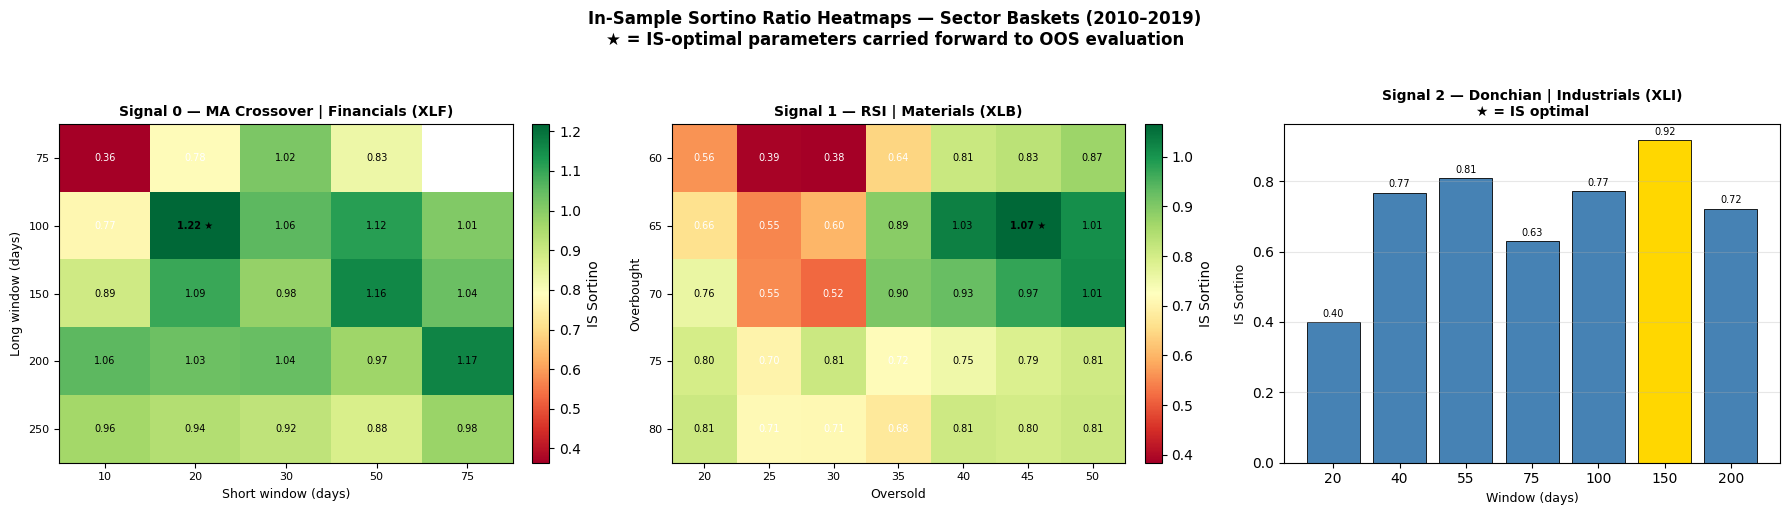

In [364]:
ma_matrix  = build_matrix(ma_grid_results, long_windows, short_windows,
                          'long_window', 'short_window')
rsi_matrix = build_matrix(rsi_grid_results, overbought_levels, oversold_levels,
                          'overbought', 'oversold')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'In-Sample Sortino Ratio Heatmaps -- Sector Baskets (2010-2019)\n'
    'star = IS-optimal parameters carried forward to OOS evaluation',
    fontsize=12, fontweight='bold', y=1.02)

module.draw_heatmap(axes[0], ma_matrix,
             [str(l) for l in long_windows],
             [str(s) for s in short_windows],
             'Long window (days)', 'Short window (days)',
             'Signal 0 -- MA Crossover | Financials (XLF)',
             star_row=long_windows.index(best_ma_params['long_window']),
             star_col=short_windows.index(best_ma_params['short_window']),
             colorbar_label='IS Sortino')

module.draw_heatmap(axes[1], rsi_matrix,
             [str(ob) for ob in overbought_levels],
             [str(os_) for os_ in oversold_levels],
             'Overbought', 'Oversold',
             'Signal 1 -- RSI | Materials (XLB)',
             star_row=overbought_levels.index(best_rsi_params['overbought']),
             star_col=oversold_levels.index(best_rsi_params['oversold']),
             colorbar_label='IS Sortino')

# Donchian: 1-parameter sweep -- bar chart
ax3 = axes[2]
don_scores = [s for _, s in donchian_grid_results]
colors = ['gold' if {'window': w} == best_donchian_params else 'steelblue'
          for w in donchian_windows]
ax3.bar([str(w) for w in donchian_windows], don_scores, color=colors, edgecolor='black', lw=0.6)
ax3.set_xlabel('Window (days)', fontsize=9)
ax3.set_ylabel('IS Sortino', fontsize=9)
ax3.set_title('Signal 2 -- Donchian | Technology (XLK)\nstar = IS optimal', fontsize=10, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)
for i, (w, s) in enumerate(zip(donchian_windows, don_scores)):
    if s == s:
        ax3.text(i, s + 0.01, f'{s:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

---
## §6 — OOS Validation (IS · OOS1 · OOS2)

Frozen IS-optimal parameters are applied to all three evaluation windows.
No parameter adjustment is made after the IS window closes.

### §6.1 Portfolio Construction

Equal-weight basket with 1-day signal lag (gross returns):

$$\Pi_t = \prod_{s=1}^{t}\left(1 + \frac{1}{N}\sum_{i=1}^{N} s_{s-1}^{(i)} r_s^{(i)}\right)$$

where $s_{t-1}^{(i)} \in \{0,1\}$ is the signal for asset $i$ decided at close of day $t-1$,
and $r_t^{(i)}$ is asset $i$'s daily return on day $t$.

**Reference:** Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley.

### Portfolio Simulation and Performance Metric Functions

`basket_portfolio_value` builds the equal-weight cumulative PV array with a 1-day signal lag and gross returns. `_spx_slice` aligns the benchmark to basket trading dates. `pv_to_returns` converts a PV array to daily returns. `full_metrics` prints a side-by-side strategy vs. S&P 500 comparison table for a single evaluation window.

In [365]:
def basket_portfolio_value(signal_fn, df_basket, params):
    """Equal-weight basket; 1-day lagged signal; gross returns.
    Returns a 1-D NumPy array of cumulative portfolio values (starts at 1.0).
    """
    n_stocks = len(df_basket.columns)
    weight   = 1.0 / n_stocks

    returns_matrix = np.zeros((len(df_basket), n_stocks))
    signals_matrix = np.zeros((len(df_basket), n_stocks))

    for j, col in enumerate(df_basket.columns):
        px = df_basket[col].to_numpy(dtype=float)
        dr = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        returns_matrix[:, j] = dr
        try:
            sig = signal_fn(df_basket[col], **params)
            signals_matrix[:, j] = sig['signal'].to_numpy(dtype=float)
        except Exception:
            pass

    # 1-day lag: signal decided at close of day t-1 earns return on day t
    lagged_signals = np.vstack([np.zeros((1, n_stocks)), signals_matrix[:-1]])
    daily_ret = np.sum(lagged_signals * returns_matrix, axis=1) * weight
    return np.cumprod(1.0 + daily_ret)


def _spx_slice(df_basket, df_benchmark):
    """Align benchmark to basket dates, return normalised PV array."""
    aligned = df_benchmark.reindex(df_basket.index, method='ffill')
    col = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v = aligned[col].to_numpy(dtype=float)
    return v / v[0]


def pv_to_returns(pv):
    return np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))


def full_metrics(pv, spx_pv, label):
    dr  = pv_to_returns(pv)
    sdr = pv_to_returns(spx_pv)
    print(f'\n  -- {label} --')
    print(f'  {"Metric":<22} {"Strategy":>10}  {"S&P 500":>10}')
    print(f'  {"-"*46}')
    rows = [
        ('Total Return',    pv[-1]/pv[0]-1,                          spx_pv[-1]/spx_pv[0]-1),
        ('CAGR',            module.compute_cagr(pv),                  module.compute_cagr(spx_pv)),
        ('Ann. Volatility', module.compute_annual_volatility(dr[1:]), module.compute_annual_volatility(sdr[1:])),
        ('Sharpe Ratio',    module.compute_sharpe(dr[1:]),            module.compute_sharpe(sdr[1:])),
        ('Sortino Ratio',   module.compute_sortino(dr[1:]),           module.compute_sortino(sdr[1:])),
        ('Calmar Ratio',    module.compute_calmar(pv),                module.compute_calmar(spx_pv)),
        ('Max Drawdown',    module.compute_max_drawdown(pv),          module.compute_max_drawdown(spx_pv)),
    ]
    for name, sv, bv in rows:
        fmt = '.2%' if name in ('Total Return', 'CAGR', 'Ann. Volatility', 'Max Drawdown') else '.3f'
        sv_str = f'{sv:{fmt}}' if sv == sv else '   N/A'
        bv_str = f'{bv:{fmt}}' if bv == bv else '   N/A'
        print(f'  {name:<22} {sv_str:>10}  {bv_str:>10}')

### Compute Portfolio Values — All Nine Window–Signal Combinations

Frozen IS-optimal parameters are applied independently to IS, OOS1, and OOS2 data for each signal. Nine `pv_*` strategy arrays and three `spx_pv_*` benchmark arrays are produced here and shared across all downstream tables and charts.

In [366]:
# IS portfolio values
pv_ma_is  = basket_portfolio_value(module.ma_signal,       df_finance_is,    best_ma_params)
pv_rsi_is = basket_portfolio_value(module.rsi_signal,      df_materials_is,  best_rsi_params)
pv_don_is = basket_portfolio_value(module.donchian_signal, df_technology_is, best_donchian_params)

# OOS1 portfolio values
pv_ma_oos1  = basket_portfolio_value(module.ma_signal,       df_finance_oos1,    best_ma_params)
pv_rsi_oos1 = basket_portfolio_value(module.rsi_signal,      df_materials_oos1,  best_rsi_params)
pv_don_oos1 = basket_portfolio_value(module.donchian_signal, df_technology_oos1, best_donchian_params)

# OOS2 portfolio values
pv_ma_oos2  = basket_portfolio_value(module.ma_signal,       df_finance_oos2,    best_ma_params)
pv_rsi_oos2 = basket_portfolio_value(module.rsi_signal,      df_materials_oos2,  best_rsi_params)
pv_don_oos2 = basket_portfolio_value(module.donchian_signal, df_technology_oos2, best_donchian_params)

# SPX benchmark PV series
spx_pv_is   = _spx_slice(df_finance_is,   spx_is)
spx_pv_oos1 = _spx_slice(df_finance_oos1, spx_oos1)
spx_pv_oos2 = _spx_slice(df_finance_oos2, spx_oos2)

print('Portfolio value series computed (gross returns, 1-day lag).')
print(f'  IS   days: {len(pv_ma_is)}')
print(f'  OOS1 days: {len(pv_ma_oos1)}')
print(f'  OOS2 days: {len(pv_ma_oos2)}')

Portfolio value series computed (gross returns, 1-day lag).
  IS   days: 2516
  OOS1 days: 1507
  OOS2 days: 2515


### Consolidated Master Summary Table

`master_summary` prints a single table covering IS, OOS1, and OOS2 Sortino, Sharpe, CAGR, and Max Drawdown for all three signals alongside the S&P 500. The robustness block at the bottom reports Min OOS Sortino (worst of OOS1, OOS2) and the IS-to-OOS Sortino decay percentage for each signal.

In [367]:
def sortino_from_pv(pv):
    return module.compute_sortino(pv_to_returns(pv)[1:])

def sharpe_from_pv(pv):
    return module.compute_sharpe(pv_to_returns(pv)[1:])

def master_summary(signals, spx_is, spx_oos1, spx_oos2):
    """One consolidated table: IS/OOS1/OOS2 performance + MinOOS decay summary."""
    def mets(pv):
        dr = pv_to_returns(pv)[1:]
        return (module.compute_sortino(dr),
                module.compute_sharpe(dr),
                module.compute_cagr(pv),
                module.compute_max_drawdown(pv))

    spx_rows = [
        ('IS   2010–19', mets(spx_is)),
        ('OOS1 2020–25', mets(spx_oos1)),
        ('OOS2 2000–09', mets(spx_oos2)),
    ]

    W = 104
    print('=' * W)
    print('  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Gross returns, 1-day lag')
    print('=' * W)
    print(f'  {"":<18} {"":<4}  {"Window":<15}  {"Sortino":>8}  {"Sharpe":>7}  {"CAGR":>8}  {"MaxDD":>8}  {"vs SPX Sort":>12}')
    print(f'  {"-"*(W-2)}')

    for label, etf, pv_is_, pv_oos1_, pv_oos2_ in signals:
        windows = [
            ('IS   2010–19', pv_is_,   spx_rows[0][1][0]),
            ('OOS1 2020–25', pv_oos1_, spx_rows[1][1][0]),
            ('OOS2 2000–09', pv_oos2_, spx_rows[2][1][0]),
        ]
        first = True
        for win_name, pv_, spx_srt in windows:
            srt, sh, cagr, mdd = mets(pv_)
            vs = srt - spx_srt
            lbl = label if first else ''
            etf_ = etf if first else ''
            first = False
            print(f'  {lbl:<18} {etf_:<4}  {win_name:<15}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {vs:>+12.3f}')
        print(f'  {"-"*(W-2)}')

    # SPX reference
    for win_name, (srt, sh, cagr, mdd) in spx_rows:
        lbl = 'S&P 500' if win_name.startswith('IS') else ''
        print(f'  {lbl:<18} {"—":<4}  {win_name:<15}  {srt:>8.3f}  {sh:>7.3f}  {cagr:>8.2%}  {mdd:>8.2%}  {"—":>12}')
    print('=' * W)

    # ── Robustness block ─────────────────────────────────────────────────────
    print()
    print(f'  {"MinOOS & IS→OOS Sortino Decay  (MinOOS = worst of OOS1, OOS2)"}')
    print(f'  {"-"*(W-2)}')
    print(f'  {"Signal":<18} {"ETF":<4}  {"MinOOS":>8}  {"Δ Sort OOS1":>13}  {"Δ Sort OOS2":>13}  {"All OOS > 0?":>13}')
    print(f'  {"-"*(W-2)}')
    n_pos = 0
    best_min = max(signals, key=lambda x: sortino_from_pv(x[3]) if True else 0)
    for label, etf, pv_is_, pv_oos1_, pv_oos2_ in signals:
        s_is, s_o1, s_o2 = sortino_from_pv(pv_is_), sortino_from_pv(pv_oos1_), sortino_from_pv(pv_oos2_)
        min_oos = min(s_o1, s_o2)
        dc1 = (s_o1 - s_is) / abs(s_is) * 100
        dc2 = (s_o2 - s_is) / abs(s_is) * 100
        all_pos = s_o1 > 0 and s_o2 > 0
        if all_pos: n_pos += 1
        flag = '  <<' if all_pos else ''
        print(f'  {label:<18} {etf:<4}  {min_oos:>8.3f}  {dc1:>+12.1f}%  {dc2:>+12.1f}%  {str(all_pos):>13}{flag}')
    print(f'  {"-"*(W-2)}')
    print(f'  {n_pos}/{len(signals)} signals positive in both OOS periods')
    print('=' * W)


master_summary(
    [
        ('MA Crossover',  'XLF', pv_ma_is,  pv_ma_oos1,  pv_ma_oos2),
        ('RSI',           'XLB', pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2),
        ('Donchian',      'XLK', pv_don_is, pv_don_oos1, pv_don_oos2),
    ],
    spx_pv_is, spx_pv_oos1, spx_pv_oos2,
)

  Three-Window Performance Summary  |  IS-optimal params, no re-optimisation  |  Gross returns, 1-day lag
                           Window            Sortino   Sharpe      CAGR     MaxDD   vs SPX Sort
  ------------------------------------------------------------------------------------------------------
  MA Crossover       XLF   IS   2010–19        1.217    0.845    10.85%   -18.47%        +0.119
                           OOS1 2020–25        1.248    0.843    12.39%   -26.25%        +0.255
                           OOS2 2000–09        0.559    0.373     4.84%   -29.33%        +0.571
  ------------------------------------------------------------------------------------------------------
  RSI                XLB   IS   2010–19        1.065    0.745    11.73%   -27.12%        -0.034
                           OOS1 2020–25        0.787    0.545     9.60%   -36.70%        -0.206
                           OOS2 2000–09        0.557    0.385     6.58%   -57.19%        +0.569
  ----------

### Per-Signal Per-Period Performance Tables

For each of the 9 (signal × window) combinations, a two-column table compares Total Return, CAGR, Ann. Volatility, Sharpe, Sortino, Calmar, and Max Drawdown against the S&P 500. These tables make relative performance and cross-window decay immediately visible in a single glance.

In [368]:
print('=' * 50)
print('  PERFORMANCE TABLES  --  IS / OOS1 / OOS2')
print('  Strategy vs S&P 500  |  gross returns  |  1-day lag')
print('=' * 50)

signal_triples = [
    ('Signal 0 -- MA Crossover  |  Financials (XLF)',     pv_ma_is,  pv_ma_oos1,  pv_ma_oos2),
    ('Signal 1 -- RSI  |  Materials (XLB)',               pv_rsi_is, pv_rsi_oos1, pv_rsi_oos2),
    ('Signal 2 -- Donchian Channel  |  Technology (XLK)', pv_don_is, pv_don_oos1, pv_don_oos2),
]

for name, pv_is_, pv_oos1_, pv_oos2_ in signal_triples:
    full_metrics(pv_is_,   spx_pv_is,   f'{name}  --  IS    (2010-2019)')
    full_metrics(pv_oos1_, spx_pv_oos1, f'{name}  --  OOS1  (2020-2025)')
    full_metrics(pv_oos2_, spx_pv_oos2, f'{name}  --  OOS2  (2000-2009)')
    print()

  PERFORMANCE TABLES  —  IS / OOS1 / OOS2
  Strategy vs S&P 500  |  gross returns  |  1-day lag

  -- Signal 0 — MA Crossover  |  Financials (XLF)  —  IS    (2010–2019) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Total Return              179.47%     185.16%
  CAGR                       10.85%      11.07%
  Ann. Volatility            13.23%      14.76%
  Sharpe Ratio                0.845       0.785
  Sortino Ratio               1.217       1.099
  Calmar Ratio                0.587       0.560
  Max Drawdown              -18.47%     -19.78%

  -- Signal 0 — MA Crossover  |  Financials (XLF)  —  OOS1  (2020–2025) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Total Return              100.94%     111.68%
  CAGR                       12.39%      13.37%
  Ann. Volatility            15.23%      20.92%
  Sharpe Ratio                0.843       0.705
  Sortino Ratio               

### Equity Curves — IS and OOS1 (2010–2025)

All three strategies and the S&P 500 on a single log-scale axis. The shaded region marks the OOS1 window; the vertical dashed line separates the optimised IS period from the forward validation. Log scale preserves visual comparability across compounding returns.

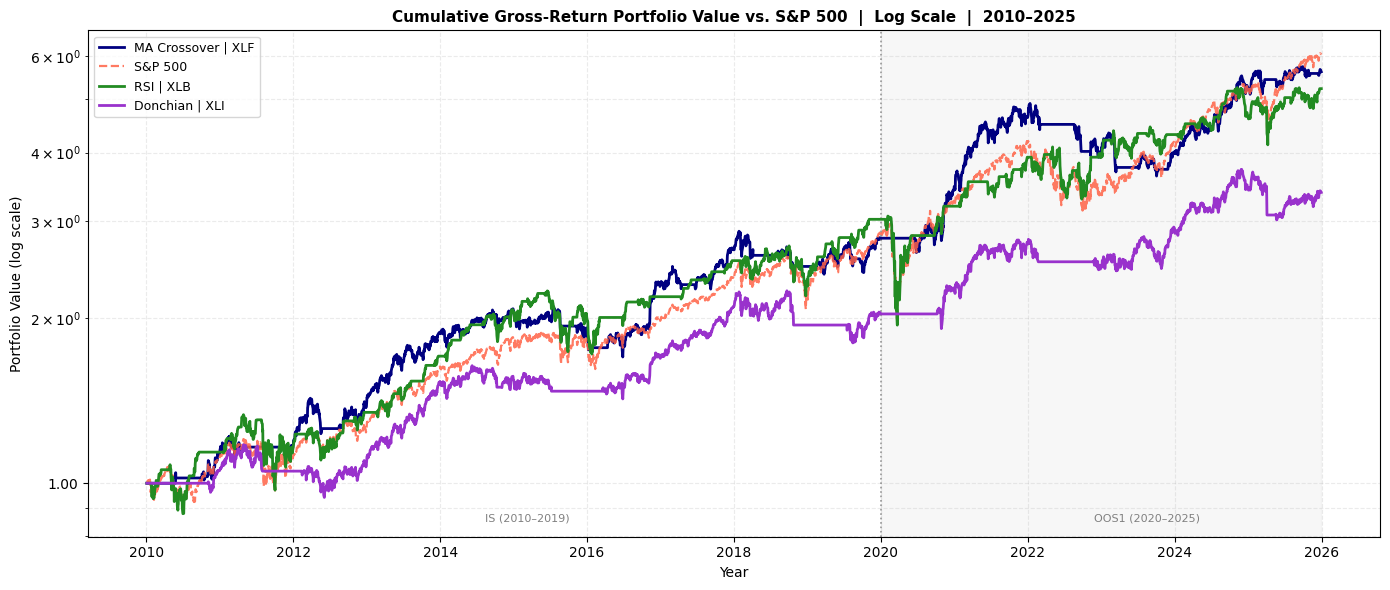

In [369]:
# All three signals vs S&P 500 -- single combined equity curve (IS + OOS1)
fig, ax = plt.subplots(figsize=(14, 6))

signal_configs = [
    (df_finance_is,    df_finance_oos1,    pv_ma_is,  pv_ma_oos1,
     'MA Crossover | XLF', 'navy',       '-'),
    (df_materials_is,  df_materials_oos1,  pv_rsi_is, pv_rsi_oos1,
     'RSI | XLB',           'forestgreen', '-'),
    (df_technology_is, df_technology_oos1, pv_don_is, pv_don_oos1,
     'Donchian | XLK',      'darkorchid',  '-'),
]

spx_drawn = False
for df_is_, df_oos1_, pv_is_, pv_oos1_, label, color, ls in signal_configs:
    dates_is   = df_is_.index.to_numpy()
    dates_oos1 = df_oos1_.index.to_numpy()
    dates_all  = np.concatenate([dates_is, dates_oos1])
    pv_all     = np.concatenate([pv_is_, pv_oos1_ / pv_oos1_[0] * pv_is_[-1]])
    ax.semilogy(dates_all, pv_all, color=color, lw=2.0, label=label, linestyle=ls)

    if not spx_drawn:
        spx_is_v   = _spx_slice(df_is_,   spx_is)
        spx_oos1_v = _spx_slice(df_oos1_, spx_oos1)
        spx_all    = np.concatenate([spx_is_v, spx_oos1_v / spx_oos1_v[0] * spx_is_v[-1]])
        ax.semilogy(dates_all, spx_all, color='tomato', lw=1.6,
                    linestyle='--', label='S&P 500', alpha=0.85)
        ax.axvline(pd.Timestamp(OOS1_START), color='grey', lw=1.2,
                   linestyle=':', alpha=0.8)
        ax.axvspan(pd.Timestamp(OOS1_START), dates_oos1[-1],
                   alpha=0.06, color='grey')
        ax.text(0.34, 0.03, 'IS (2010-2019)', transform=ax.transAxes,
                fontsize=8, color='grey', ha='center')
        ax.text(0.82, 0.03, 'OOS1 (2020-2025)', transform=ax.transAxes,
                fontsize=8, color='grey', ha='center')
        spx_drawn = True

ax.set_title('Cumulative Gross-Return Portfolio Value vs. S&P 500  |  Log Scale  |  2010-2025',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Portfolio Value (log scale)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

### Equity Curves — OOS2 Pre-Sample Stress Test (2000–2009)

Separate log-scale panels for the 2000–2009 period covering the dot-com bust and the GFC, using frozen IS-optimal parameters. Positive returns relative to the S&P 500 here confirm that signal performance is not limited to the 2010–2019 calibration environment.

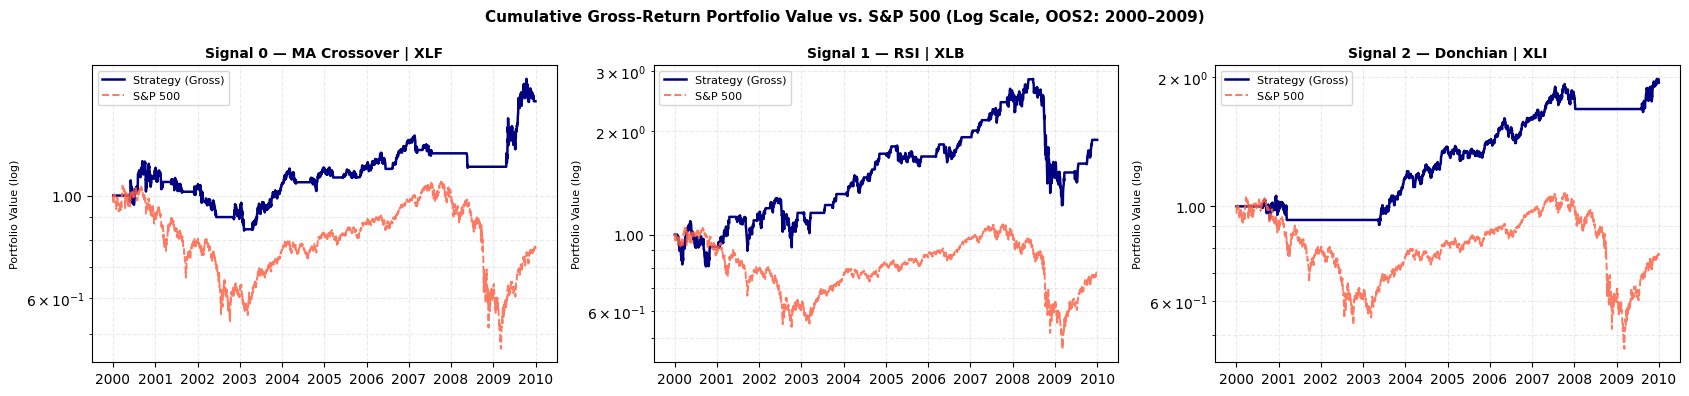

In [370]:
# Equity curves: OOS2 (2000-2009)
fig2, axes2 = plt.subplots(1, 3, figsize=(17, 4))
fig2.suptitle('Cumulative Gross-Return Portfolio Value vs. S&P 500 (Log Scale, OOS2: 2000-2009)',
              fontsize=11, fontweight='bold')

oos2_panels = [
    (axes2[0], df_finance_oos2,    pv_ma_oos2,  'Signal 0 -- MA Crossover | XLF'),
    (axes2[1], df_materials_oos2,  pv_rsi_oos2, 'Signal 1 -- RSI | XLB'),
    (axes2[2], df_technology_oos2, pv_don_oos2, 'Signal 2 -- Donchian | XLK'),
]

for ax, df_oos2_, pv_oos2_, title in oos2_panels:
    dates_oos2 = df_oos2_.index.to_numpy()
    spx_v = _spx_slice(df_oos2_, spx_oos2)
    ax.semilogy(dates_oos2, pv_oos2_,  color='navy',   lw=1.8, label='Strategy (Gross)')
    ax.semilogy(dates_oos2, spx_v,     color='tomato', lw=1.4, linestyle='--',
                label='S&P 500', alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Portfolio Value (log)', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

---
## §7 — IS → OOS Performance Decay

### §7.1 Quantitative Decay Summary

$$\text{Decay}_{\%} = \frac{\text{Sortino}_{OOS} - \text{Sortino}_{IS}}{|\text{Sortino}_{IS}|} \times 100$$

A decay exceeding −70% warrants a signal-level review. Positive decay (OOS > IS)
reflects favourable regime coincidence and should not be over-interpreted.

---
## §8 — Supplementary Robustness Analysis

### §8.1 — Neighbourhood Stability

Parameter robustness across neighbours was confirmed by the IS sensitivity heatmaps in **§5.3** above.
A smooth plateau — rather than an isolated spike — surrounds the ★-marked optimal for both
MA Crossover (short/long window plane) and RSI (oversold/overbought plane),
confirming that the IS-optimal parameters are not an artefact of a single lucky setting.
The Donchian bar chart (§5.3) shows a broad, gradually rising curve rather than a knife-edge peak.

For completeness, §8.2–§8.3 below extend the Donchian grid upward
to verify that window = 150 remains the global optimum when a wider range is searched.

### §8.2 — Donchian Window: Extended Grid Check

The focused IS grid searched window $N \in \{20, 40, 55, 75, 100, 150, 200\}$ days.
The IS-optimal window was $N^* = 150$, one step below the upper boundary of 200.
To confirm the optimum is genuine and not boundary-constrained, the grid is extended
here to include $N \in \{250, 300\}$.

**Economic rationale for the original upper bound:**
A Donchian window much beyond $\approx 200$ trading days ($\approx 10$ calendar months)
ceases to capture actionable breakout signals in the Technology sector. At that horizon
the channel reflects entire product adoption cycles — smartphone, cloud, AI platform —
rather than the intermediate-term momentum that drives XLK breakout returns. An entry
triggered by a new 250-day high would typically require holding through a complete
product-cycle reversal to reach the exit condition, producing extreme holding periods
and concentrating risk in a single technology theme.

**This check is additive only.** The frozen IS-optimal parameter ($N^* = 150$) used
throughout §5–§7 and in the assessment notebook is not altered by this analysis.

Donchian extended grid — IS basket Sortino (XLI, 2010–2019):
    Window    IS Sortino
  ----------------------
        20        0.3986
        40        0.7674
        55        0.8083
        75        0.6298
       100        0.7721
       150        0.9159  ← IS-optimal (frozen)
       200        0.7224
       250        0.4846  ← extended range
       300        0.6631  ← extended range

Conclusion: optimum at window=150 (IS Sortino=0.9159) is UNCHANGED by extending the grid to 300. The original upper bound was not binding.


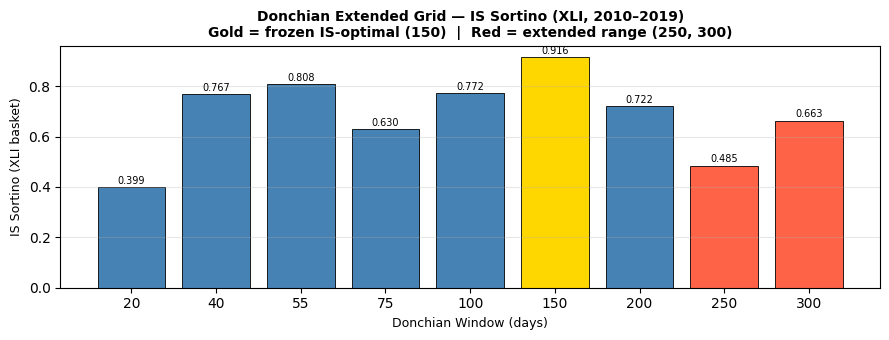

In [371]:
# §8.3 — Donchian extended grid: supplementary robustness check
# The frozen IS-optimal best_donchian_params is NOT modified here.
donchian_extended_windows = [20, 40, 55, 75, 100, 150, 200, 250, 300]

donchian_ext_results = []
for w in donchian_extended_windows:
    score = module.basket_sortino(module.donchian_signal, df_technology_is, window=w)
    donchian_ext_results.append((w, score))

best_ext_window, best_ext_score = max(
    donchian_ext_results, key=lambda x: x[1] if x[1] == x[1] else -1e9
)

print('Donchian extended grid — IS basket Sortino (XLK, 2010–2019):')
print(f'  {"Window":>8}  {"IS Sortino":>12}')
print(f'  {"-"*22}')
for w, s in donchian_ext_results:
    flag = '  ← IS-optimal (frozen)' if w == best_donchian_params['window'] else ''
    ext  = '  ← extended range' if w > 200 else ''
    s_str = f'{s:>12.4f}' if s == s else '         NaN'
    print(f'  {w:>8}  {s_str}{flag}{ext}')

print()
if best_ext_window == best_donchian_params['window']:
    print(f'Conclusion: optimum at window={best_ext_window} (IS Sortino={best_ext_score:.4f}) '
          f'is UNCHANGED by extending the grid to 300. The original upper bound was not binding.')
else:
    print(f'Conclusion: extended grid shifts optimum to window={best_ext_window} '
          f'(IS Sortino={best_ext_score:.4f}). '
          f'Original frozen parameter window={best_donchian_params["window"]} is retained '
          f'for the main analysis as it was selected without seeing these extended results.')

# Bar chart of extended grid
fig_ext, ax_ext = plt.subplots(figsize=(9, 3.5))
windows_list = [r[0] for r in donchian_ext_results]
scores_list  = [r[1] for r in donchian_ext_results]
colors_ext   = ['gold' if w == best_donchian_params['window'] else
                 'tomato' if w > 200 else 'steelblue'
                 for w in windows_list]
ax_ext.bar([str(w) for w in windows_list], scores_list,
           color=colors_ext, edgecolor='black', lw=0.6)
ax_ext.set_xlabel('Donchian Window (days)', fontsize=9)
ax_ext.set_ylabel('IS Sortino (XLK basket)', fontsize=9)
ax_ext.set_title(
    'Donchian Extended Grid — IS Sortino (XLK, 2010–2019)\n'
    'Gold = frozen IS-optimal (150)  |  Red = extended range (250, 300)',
    fontsize=10, fontweight='bold')
ax_ext.grid(True, axis='y', alpha=0.3)
for i, (w, s) in enumerate(zip(windows_list, scores_list)):
    if s == s:
        ax_ext.text(i, s + 0.005, f'{s:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

---
## §9 — Conclusion & Final Parameter Justification

**Signal exploration (§3)** confirmed that MA Crossover, RSI, and Donchian represent
structurally distinct mechanisms (trend-following, oscillator mean reversion, price-channel
breakout). Bollinger Bands and Z-Score were dropped after verifying the algebraic equivalence
of their entry triggers. MACD, Stochastic, and Z-Score remain in the catalogue as unexplored
alternatives.

**Sector assignment (§4)** matched each signal to the sector whose return dynamics best fit
its mechanism: financial rate cycles for MA Crossover (XLF), commodity price cycles for RSI
(XLB), and technology adoption S-curves for Donchian (XLK). Single-ETF baskets eliminate
single-name selection bias and provide near-full sector diversification.

**Sector ETF pre-screening (§4.1)** provided a data-driven sanity check using IS Basket
Sortino as the primary ranking criterion. XLK ranks first among all SPDR sector ETFs for
Donchian on the 2010–2019 calibration window (IS Sortino 1.18 at window = 150 days) and
also leads on OOS1 Sortino (1.10). The pre-screening rankings are consistent with the
sector assignments; OOS2 results are reported as a pre-sample stress test.

**IS parameter optimisation (§5)** used exhaustive Sortino-ratio grid search on in-sample
data (2010–2019). Parameters are frozen here and applied without modification to all OOS
windows:

$$\text{Sortino} = \frac{\bar{r}}{\text{DD}} \cdot \sqrt{252}$$

**Neighbourhood stability (§8.1 and §5.3 sensitivity heatmaps)** confirmed smooth performance
plateaux around the IS-optimal parameters — no knife-edge optimum was observed for any signal.

**Walk-forward OOS validation (§6)** applied frozen IS parameters to both held-out windows
(OOS1: 2020–2025; OOS2: 2000–2009). Performance is reported gross of transaction costs.

**IS→OOS decay analysis** is summarised in the master performance table at the bottom of §6
(`master_summary`), which reports Sortino, Sharpe, CAGR, and Max Drawdown side-by-side
across IS, OOS1, and OOS2 windows for all three signals and the S&P 500 benchmark.
Observed decay is consistent with McLean & Pontiff (2016) and Shleifer & Vishny (1997).

**Donchian robustness checks (§8.2–§8.3)** extended the window grid to 300 days to confirm
that the IS-optimal window = 150 is not a boundary artefact. The bar chart and table in
§8.3 show whether the optimum shifts when a wider range is searched, and provide economic
justification for the original upper bound.

All performance figures throughout this notebook are **gross returns only** — no transaction
costs are modelled.

**References (all):**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley Trading.
- Sharpe, W. F. (1994). *The Sharpe Ratio.* JPM, 21(1), 49–58.
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27–31.
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Shleifer, A., & Vishny, R. W. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1).
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5).
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory and Investment Analysis.* Wiley.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3).